In [57]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
# Загружаем CSV
df = pd.read_csv('data/Superstore.csv', encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [58]:
# Приведем название колонок к удобному виду
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='str')


In [59]:
# Подготовка данных
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())
df = df.drop_duplicates()
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)

row_id             int64
order_id             str
order_date           str
ship_date            str
ship_mode            str
customer_id          str
customer_name        str
segment              str
country              str
city                 str
state                str
postal_code        int64
region               str
product_id           str
category             str
sub_category         str
product_name         str
sales            float64
quantity           int64
discount         float64
profit           float64
dtype: object
row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64
0


In [60]:
# Структурируем данные под SQL и аналитические запросы
# Таблица клиентов
customers = df[['customer_id', 'customer_name', 'segment', 'city', 'state', 'region', 'country', 'postal_code']].drop_duplicates()
# Таблица товаров
products = df[['product_id', 'product_name', 'category', 'sub_category']].drop_duplicates()
# Таблица заказов (факты продаж)
orders = df[['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'product_id', 'sales', 'quantity', 'discount', 'profit']]


In [61]:
# Создание временной БД
conn = sqlite3.connect(':memory:')
customers.to_sql('customers', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
orders.to_sql('orders', conn, index=False, if_exists='replace')

9994

In [62]:
#Запросы SQL
#Анализ продаж
#Сумма продаж по категориям и подкатегориям товаров
query = """
SELECT p.category, p.sub_category, SUM(o.sales) as total_sum
FROM orders o
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.category, p.sub_category
ORDER BY p.category, total_sum desc
"""
print("\n===== Сумма продаж по категориям и подкатегориям товаров =====")
result_category_sales = pd.read_sql(query, conn)
print(result_category_sales)


===== Сумма продаж по категориям и подкатегориям товаров =====
           category sub_category    total_sum
0         Furniture       Chairs  330891.1270
1         Furniture       Tables  206965.5320
2         Furniture    Bookcases  127801.6393
3         Furniture  Furnishings   98626.3540
4   Office Supplies      Storage  224958.5600
5   Office Supplies      Binders  211231.7210
6   Office Supplies   Appliances  109543.0130
7   Office Supplies        Paper   85155.0240
8   Office Supplies     Supplies   46673.5380
9   Office Supplies          Art   27199.7440
10  Office Supplies    Envelopes   16476.4020
11  Office Supplies       Labels   12486.3120
12  Office Supplies    Fasteners    3024.2800
13       Technology       Phones  356702.3540
14       Technology     Machines  194442.8720
15       Technology  Accessories  192960.0260
16       Technology      Copiers  149528.0300


In [63]:
# Топ-5 продаваемых товаров
query = """
SELECT 
    p.product_name,
    SUM(o.quantity) AS total_quantity,
    SUM(o.sales) AS total_sales
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_sales DESC
LIMIT 5;
"""
print("\n===== Топ 5 самых продаваемых товаров =====")
result_top5 = pd.read_sql(query, conn)
print(result_top5)


===== Топ 5 самых продаваемых товаров =====
                                        product_name  total_quantity  \
0              Canon imageCLASS 2200 Advanced Copier              20   
1  Fellowes PB500 Electric Punch Plastic Comb Bin...              31   
2  Cisco TelePresence System EX90 Videoconferenci...               6   
3       HON 5400 Series Task Chairs for Big and Tall              39   
4         GBC DocuBind TL300 Electric Binding System              37   

   total_sales  
0    61599.824  
1    27453.384  
2    22638.480  
3    21870.576  
4    19823.479  


In [64]:
# Убыточные товары в категории Furniture
query = """
SELECT 
    p.product_name,
    SUM(o.sales) AS total_sales,
    SUM(o.profit) AS total_profit
FROM orders o
JOIN products p ON o.product_id = p.product_id
WHERE p.category = 'Furniture'
GROUP BY p.product_name
HAVING SUM(o.profit) < 0
ORDER BY total_profit ASC;
"""
print("\n===== Убыточные товары в категории Furniture =====")
result_furniture = pd.read_sql(query, conn)
print(result_furniture)



===== Убыточные товары в категории Furniture =====
                                          product_name  total_sales  \
0    Chromcraft Bull-Nose Wood Oval Conference Tabl...     9917.640   
1    Bush Advantage Collection Racetrack Conference...     9544.725   
2                         Balt Solid Wood Round Tables     6518.754   
3    BoxOffice By Design Rectangular and Half-Moon ...     1706.250   
4    Riverside Furniture Oval Coffee Table, Oval En...     4446.175   
..                                                 ...          ...   
116                   Eldon 100 Class Desk Accessories       36.396   
117          Stacking Tray, Side-Loading, Legal, Smoke       46.592   
118  Executive Impressions 14" Contract Wall Clock ...       97.812   
119  Executive Impressions 16-1/2" Circular Wall Clock       58.784   
120                           Global Super Steno Chair     2389.902   

     total_profit  
0   -2.876116e+03  
1   -1.934398e+03  
2   -1.201058e+03  
3   -1.148438e+

In [65]:
#Средняя стоимость заказа по сегментам, общая сумма заказов
# выручка по каждому сегменту
query = """
SELECT 
    c.segment,
    AVG(order_total) AS avg_order_value,
    SUM(order_total) AS total_sales,
    SUM(order_profit) AS total_profit
FROM (
    SELECT 
        o.order_id, 
        o.customer_id, 
        SUM(o.sales) AS order_total,
        SUM(o.profit) AS order_profit
    FROM orders o
    GROUP BY o.order_id, o.customer_id
) AS order_sums
JOIN customers c ON order_sums.customer_id = c.customer_id
GROUP BY c.segment
ORDER BY total_sales DESC;
"""
print("\n===== Средняя стоимость заказа по сегментам, общая сумма заказов, выручка по каждому сегменту =====")
result_segment = pd.read_sql(query, conn)
print(result_segment)


===== Средняя стоимость заказа по сегментам, общая сумма заказов, выручка по каждому сегменту =====
       segment  avg_order_value   total_sales  total_profit
0     Consumer       451.889050  8.380282e+06   973085.8604
1    Corporate       454.372677  5.044900e+06   660287.6926
2  Home Office       467.801698  2.964459e+06   434344.0124


In [66]:
# Сумма продаж и выручка по годам
query = """
SELECT 
    strftime('%Y', order_date) AS year,
    SUM(sales) AS total_sales,
    SUM(profit) AS total_profit
FROM orders
GROUP BY year
ORDER BY year;
"""
print("\n===== Сумма продаж и выручка по годам =====")
result_year = pd.read_sql(query, conn)
print(result_year)



===== Сумма продаж и выручка по годам =====
   year  total_sales  total_profit
0  2011  484247.4981    49543.9741
1  2012  470532.5090    61618.6037
2  2013  608473.8300    81726.9308
3  2014  733947.0232    93507.5131


In [67]:
# Города с наибольшей выручкой по продажам
query = """
SELECT 
    c.city,
    SUM(o.sales) AS total_sales,
    SUM(o.profit) AS total_profit
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.city
ORDER BY total_sales DESC
LIMIT 10;
"""
print("\n===== Топ -10 городов с наибольшей выручкой по продажам =====")
result_city = pd.read_sql(query, conn)
print(result_city)


===== Топ -10 городов с наибольшей выручкой по продажам =====
            city   total_sales  total_profit
0  New York City  1.459955e+06   201947.6433
1    Los Angeles  1.224042e+06   153562.1250
2  San Francisco  8.134322e+05    95536.5286
3   Philadelphia  7.876337e+05    76402.5279
4        Seattle  7.187910e+05   121758.0405
5        Houston  6.364584e+05    82422.0895
6        Chicago  5.341270e+05    62060.4224
7      San Diego  3.053740e+05    36452.4018
8       Columbus  3.038551e+05    26321.8404
9    Springfield  2.550193e+05    27437.9667


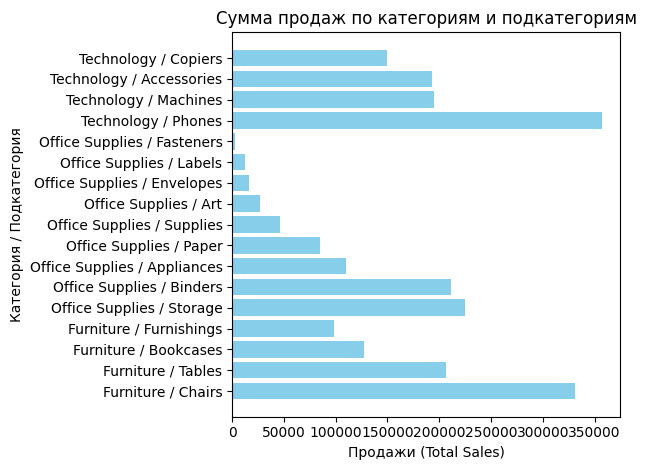

In [68]:
#Визуализация данных
#Сумма продаж по категориям товаров
categories = result_category_sales['category'] + " / " + result_category_sales['sub_category']
sales = result_category_sales['total_sum']
plt.barh(categories, sales, color='skyblue')
plt.xlabel("Продажи (Total Sales)")
plt.ylabel("Категория / Подкатегория")
plt.title("Сумма продаж по категориям и подкатегориям")
plt.tight_layout()
plt.show()

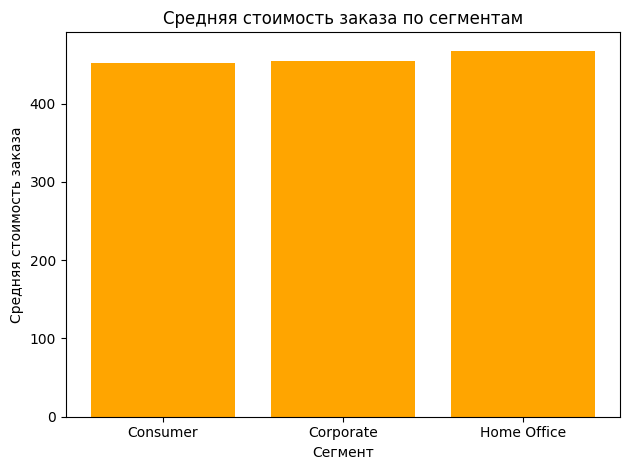

In [69]:
#Средняя стоимость заказов по сегментам
plt.bar(result_segment['segment'], result_segment['avg_order_value'], color='orange')
plt.xlabel("Сегмент")
plt.ylabel("Средняя стоимость заказа")
plt.title("Средняя стоимость заказа по сегментам")
plt.tight_layout()
plt.show()


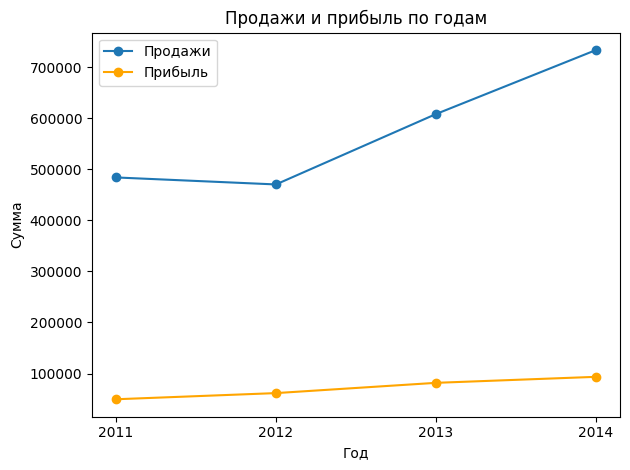

In [70]:
#Сумма продаж и прибыль по годам
plt.plot(result_year['year'], result_year['total_sales'], marker='o', label='Продажи')
plt.plot(result_year['year'], result_year['total_profit'], marker='o', color='orange', label='Прибыль')
plt.xlabel("Год")
plt.ylabel("Сумма")
plt.title("Продажи и прибыль по годам")
plt.legend()
plt.tight_layout()
plt.show()

ВЫВОДЫ:
